# Architecture of filters

So, the english is not very good, I will improve that

In [1]:
import itertools

import sympy as sy
import numpy as np

In [2]:
import fitz

from utils import plot_pdf, symmetrical_cyclic_convolution

In [3]:
doc = fitz.open('Blahut_2010_Fast algorithms for signal processing.pdf')

The base for this tutorial is the book "Fast Algorithms or Signal Processing" of Blahut.

This tutorial not work with others vector sizes

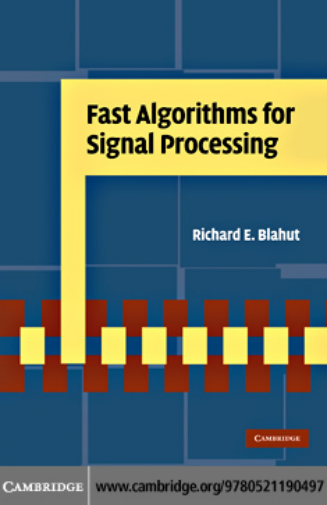

In [4]:
plot_pdf(doc[0], dpi=100)

## Polynomials

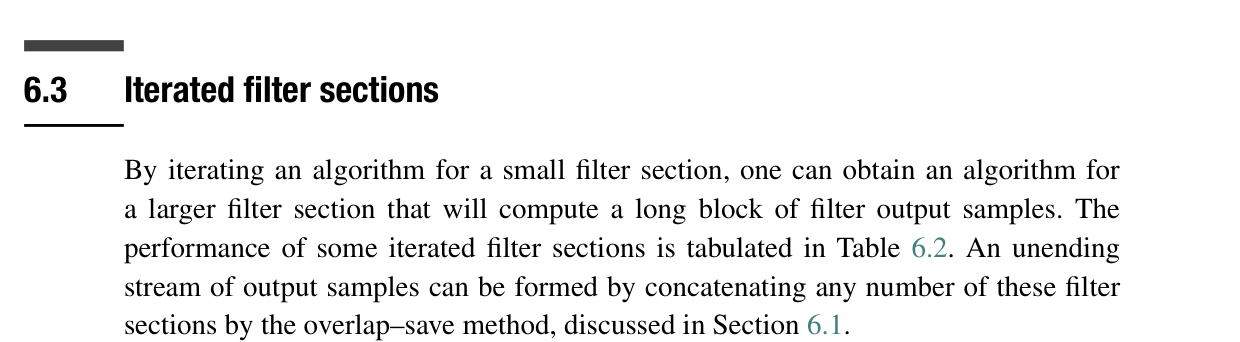

In [182]:
plot_pdf(doc[217], [.6, .78])

Size of vectors

In [45]:
d_num = 2
g_num = 2

Example of vectors for the convolution

In [46]:
d_values = list(range(1, d_num+1))
g_values = list(range(1, g_num+1))
print(d_values, g_values)

[1, 2] [1, 2]


Polynomial degree

In [47]:
d_degree = d_num - 1
g_degree = g_num - 1
print(d_degree, g_degree)

1 1


In [48]:
x = sy.symbols("x")
x

x

In [49]:
di = sy.Matrix(sy.symbols(" ".join(f"d_{i}"for i in range(d_num))))
di

Matrix([
[d_0],
[d_1]])

In [50]:
gi = sy.Matrix(sy.symbols(" ".join(f"g_{i}"for i in range(g_num))))
gi

Matrix([
[g_0],
[g_1]])

In [51]:
dx = sum([i*x**e for e, i in enumerate(di)])
dx

d_0 + d_1*x

In [52]:
gx = sum([i*x**e for e, i in enumerate(gi)])
gx

g_0 + g_1*x

In [53]:
sx = gx*dx
sx

(d_0 + d_1*x)*(g_0 + g_1*x)

Just defining values of matrices

In [54]:
a_mtx = sy.Matrix([[1, 1], [1, -1]])
a_mtx

Matrix([
[1,  1],
[1, -1]])

In [55]:
b_mtx = sy.Matrix([[1, 1], [1, -1]])
b_mtx

Matrix([
[1,  1],
[1, -1]])

In [56]:
c_mtx = sy.Matrix([[1, 1], [1, -1]])
c_mtx

Matrix([
[1,  1],
[1, -1]])

In [57]:
bg_mtx = sy.diag(*(b_mtx*gi*1/2).tolist())
bg_mtx

Matrix([
[g_0/2 + g_1/2,             0],
[            0, g_0/2 - g_1/2]])

In [58]:
sy.Matrix(np.convolve(np.array(di).reshape(-1), np.array(gi).reshape(-1)))

Matrix([
[          d_0*g_0],
[d_0*g_1 + d_1*g_0],
[          d_1*g_1]])

In [59]:
#sy.MatMul(c_mtx, bg_mtx, a_mtx, di, evaluate=True)

In [60]:
se = sy.MatMul(a_mtx.T, cd_mtx, b_mtx, gi)
se

Matrix([
[1,  1],
[1, -1]])*Matrix([
[g_0 + g_1,         0],
[        0, g_0 - g_1]])*Matrix([
[1,  1],
[1, -1]])*Matrix([
[g_0],
[g_1]])

In [66]:
se = sy.MatMul(c_mtx * bg_mtx * a_mtx, di)
se

Matrix([
[g_0, g_1],
[g_1, g_0]])*Matrix([
[d_0],
[d_1]])

In [65]:
sy.MatMul(c_mtx, bg_mtx, a_mtx, di, evaluate=True)

Matrix([
[d_0*g_0 + d_1*g_1],
[d_0*g_1 + d_1*g_0]])

In [86]:
di = sy.Matrix(sy.symbols(" ".join(f"d_{i}"for i in range(d_num*2))))
di

Matrix([
[d_0],
[d_1],
[d_2],
[d_3]])

In [68]:
gi = sy.Matrix(sy.symbols(" ".join(f"g_{i}"for i in range(g_num*2))))
gi

Matrix([
[g_0],
[g_1],
[g_2],
[g_3]])

In [69]:
si = sy.Matrix(sy.symbols(" ".join(f"s_{i}"for i in range(4))))
si

Matrix([
[s_0],
[s_1],
[s_2],
[s_3]])

In [95]:
ddi = sy.Matrix(sy.symbols(" ".join(f"D_{i}"for i in range(2))))
ddi

Matrix([
[D_0],
[D_1]])

In [71]:
ggi = sy.Matrix(sy.symbols(" ".join(f"G_{i}"for i in range(2))))
ggi

Matrix([
[G_0],
[G_1]])

In [74]:
ssi = sy.Matrix(sy.symbols(" ".join(f"S_{i}"for i in range(1, 3))))
ssi

Matrix([
[S_1],
[S_2]])

In [78]:
gg = [None for n in range(2)]

In [143]:
gg[0] = sy.Matrix([
    [gi[0], gi[3]],
    [gi[1], gi[0]]
])
gg[0]

Matrix([
[g_0, g_3],
[g_1, g_0]])

In [144]:
gg[1] = sy.Matrix([
    [gi[2], gi[1]],
    [gi[3], gi[2]]
])
gg[1]

Matrix([
[g_2, g_1],
[g_3, g_2]])

In [145]:
dd = [None for n in range(2)]
dd

[None, None]

In [146]:
dd[0] = sy.Matrix([di[0], di[1]])
dd[0]

Matrix([
[d_0],
[d_1]])

In [147]:
dd[1] = sy.Matrix([di[2], di[3]])
dd[1]

Matrix([
[d_2],
[d_3]])

In [84]:
ii = sy.symbols('I')
ii

I

In [148]:
dd_mtx = sy.Matrix([
    [ii, ii], 
    [ii, -ii]
])
dd_mtx

Matrix([
[I,  I],
[I, -I]])

In [149]:
gg_mtx = sy.diag(*[
    ggi[0] + ggi[1], 
    ggi[0]- ggi[1]
])* 1/2
gg_mtx

Matrix([
[G_0/2 + G_1/2,             0],
[            0, G_0/2 - G_1/2]])

In [150]:
cc_mtx = sy.Matrix([
    [ii, ii], 
    [ii, -ii]
])
cc_mtx

Matrix([
[I,  I],
[I, -I]])

In [151]:
sy.MatMul(cc_mtx, gg_mtx, dd_mtx, ddi)

Matrix([
[I,  I],
[I, -I]])*Matrix([
[G_0/2 + G_1/2,             0],
[            0, G_0/2 - G_1/2]])*Matrix([
[I,  I],
[I, -I]])*Matrix([
[D_0],
[D_1]])

In [168]:
cc_mtx = sy.Matrix([
    [sy.eye(2), sy.eye(2)], 
    [sy.eye(2), -sy.eye(2)]
])
cc_mtx

Matrix([
[1, 0,  1,  0],
[0, 1,  0,  1],
[1, 0, -1,  0],
[0, 1,  0, -1]])

In [160]:
dd_mtx = sy.Matrix([
    [sy.eye(2), sy.eye(2)], 
    [sy.eye(2), -sy.eye(2)]
])
dd_mtx

Matrix([
[1, 0,  1,  0],
[0, 1,  0,  1],
[1, 0, -1,  0],
[0, 1,  0, -1]])

In [155]:
gg_mtx = sy.diag(*[
    gg[0] + gg[1], 
    gg[0] - gg[1]
])* 1/2
gg_mtx

Matrix([
[g_0/2 + g_2/2, g_1/2 + g_3/2,             0,              0],
[g_1/2 + g_3/2, g_0/2 + g_2/2,             0,              0],
[            0,             0, g_0/2 - g_2/2, -g_1/2 + g_3/2],
[            0,             0, g_1/2 - g_3/2,  g_0/2 - g_2/2]])

In [179]:
gg_mtx.shape

(4, 4)

In [156]:
sy.Matrix(symmetrical_cyclic_convolution(np.array(di).reshape(-1), np.array(gi).reshape(-1)))

Matrix([
[d_0*g_0 + d_1*g_3 + d_2*g_2 + d_3*g_1],
[d_0*g_1 + d_1*g_0 + d_2*g_3 + d_3*g_2],
[d_0*g_2 + d_1*g_1 + d_2*g_0 + d_3*g_3],
[d_0*g_3 + d_1*g_2 + d_2*g_1 + d_3*g_0]])

In [169]:
ssx = sy.MatMul(cc_mtx, gg_mtx, dd_mtx, di, evaluate=True)
ssx

Matrix([
[d_0*g_0 + d_1*g_3 + d_2*g_2 + d_3*g_1],
[d_0*g_1 + d_1*g_0 + d_2*g_3 + d_3*g_2],
[d_0*g_2 + d_1*g_1 + d_2*g_0 + d_3*g_3],
[d_0*g_3 + d_1*g_2 + d_2*g_1 + d_3*g_0]])

In [170]:
ssx = sy.MatMul(cc_mtx, gg_mtx, dd_mtx, di)
ssx

Matrix([
[1, 0,  1,  0],
[0, 1,  0,  1],
[1, 0, -1,  0],
[0, 1,  0, -1]])*Matrix([
[g_0/2 + g_2/2, g_1/2 + g_3/2,             0,              0],
[g_1/2 + g_3/2, g_0/2 + g_2/2,             0,              0],
[            0,             0, g_0/2 - g_2/2, -g_1/2 + g_3/2],
[            0,             0, g_1/2 - g_3/2,  g_0/2 - g_2/2]])*Matrix([
[1, 0,  1,  0],
[0, 1,  0,  1],
[1, 0, -1,  0],
[0, 1,  0, -1]])*Matrix([
[d_0],
[d_1],
[d_2],
[d_3]])

In [173]:
subs = {k: v for k, v in zip(gi.flat(), range(0, len(gi.flat())))}
subs

{g_0: 0, g_1: 1, g_2: 2, g_3: 3}

In [174]:
gg_mtx_subs = gg_mtx.subs(subs)
gg_mtx_subs

Matrix([
[1, 2,  0,  0],
[2, 1,  0,  0],
[0, 0, -1,  1],
[0, 0, -1, -1]])

In [175]:
sy.Matrix(symmetrical_cyclic_convolution(range(len(di.flat())), range(len(gi.flat()))))

Matrix([
[10],
[12],
[10],
[ 4]])

In [178]:
r = cc_mtx * gg_mtx_subs * dd_mtx * sy.Matrix([0, 1, 2, 3])
r

Matrix([
[10],
[12],
[10],
[ 4]])